# 1. Import and Device Setting

In [53]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Helpers:
from laboneq.analysis.fitting import (oscillatory, oscillatory_decay)
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
    plot_result_2d
)

# LabOne Q:
from laboneq.simple import *

## 1.1 Parameters

In [ ]:
# a collection of qubit control and readout parameters as a python dictionary
qubit_parameters = {
    'ro_freq'       : 136e6,    # readout frequency of qubit 0 in [Hz] - relative to local oscillator for readout drive upconversion
    'ro_amp'        : 0.5,      # readout amplitude
    'ro_amp_spec'   : 0.05,     # readout amplitude for spectroscopy 0.05
    'ro_len'        : 2.0e-6,   # readout pulse length in [s]
    'ro_len_spec'   : 4.0e-6,   # readout pulse length for resonator spectroscopy in [s]
    'ro_delay'      : 0.0,      # readout delay after last drive signal in [s]
    'ro_int_delay'  : 330e-9,   # readout line offset calibration - delay between readout pulse and start of signal acquisition in [s]

    'th_res_freq'   : 0.0,  

    'qb_freq'       : 50e6,     # qubit 0 drive frequency in [Hz] - relative to local oscillator for qubit drive upconversion
    'qb_anharm'     : 200e6,    # anharmonicity
    'qb_amp_spec'   : 1e-4,     # drive amplitude of qubit spectroscopy
    'qb_len_spec'   : 15e-6,    # drive pulse length for qubit spectroscopy in [s]
    'qb_len'        : 6e-8,     # qubit drive pulse length in [s]
    'pi_amp'        : 1.0,      # qubit drive amplitude for pi pulse
    'pi_half_amp'   : 0.25,     # qubit drive amplitude for pi/2 pulse
    'qb_t1'         : 6e-6,     # qubit T1 time
    'qb_t2_ramsey'  : 1e-6,     # qubit T2 time
    'ramsey_det'    : 2e6,      # qubit frequency detuning relative to qb_freq in [Hz]
    'qb_t2_echo'    : 1e-6,     # qubit T2 time
    'relax'         : 500e-6    # delay time after each measurement for qubit reset in [s]
}

In [ ]:
lo_settings = {
    'qb_lo'     : 3.8e9,        # qubit LO frequency in [Hz]
    'ro_lo'     : 6.2e9,        # R1 readout LO frequency in [Hz]
}

## 1.2 Device Setup

In [4]:
number_of_qubits = 2

In [5]:
device_setup, qubits = generate_device_setup_qubits(
    number_qubits=number_of_qubits,
    pqsc=[{"serial": "DEV10001"}],
    hdawg=[
        {
            "serial": "DEV8001",
            "number_of_qubits": 8,
            "options": None,
        }
    ],
    shfqc=[
        {
            "serial": "DEV12001",
            "number_of_channels": 6,
            "readout_multiplex": 6,
            "options": None,
        }
    ],
    multiplex_drive_lines=True,
    include_flux_lines=False,
    server_host="localhost",
    setup_name=f"my_{number_of_qubits}_fixed_qubit_setup",
)

In [6]:
q0, q1 = qubits[:2]
for q in qubits:
    print("-------------")
    print("Qubit UID:", q.uid)
    print("Qubit logical signals:")
    for sig, lsg in q.signals.items():
        print(f"  {sig:<10} ('{lsg:>10}')")

-------------
Qubit UID: q0
Qubit logical signals:
  measure    ('q0/measure')
  acquire    ('q0/acquire')
  drive      ('  q0/drive')
  drive_ef   ('q0/drive_ef')
-------------
Qubit UID: q1
Qubit logical signals:
  measure    ('q1/measure')
  acquire    ('q1/acquire')
  drive      ('  q1/drive')
  drive_ef   ('q1/drive_ef')


In [7]:
use_emulation = True
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

[2026.06.30 15:58:09.245] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/laboneq_output/log
[2026.06.30 15:58:09.246] INFO    VERSION: laboneq 26.4.0
[2026.06.30 15:58:09.247] INFO    Connecting to data server at localhost:8004
[2026.06.30 15:58:09.248] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.30 15:58:09.249] INFO    Configuring the device setup
[2026.06.30 15:58:09.265] INFO    The device setup is configured


# 2. Resonator Spectroscopy

In [8]:
# define sweep parameter
def create_readout_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"{qubit}_res_freq",
        start=start_freq,
        stop=stop_freq,
        count=num_points,
        axis_name="Frequency [Hz]",
    )

In [9]:
# function that defines a resonator spectroscopy experiment, and takes the frequency sweep as a parameter


def res_spectroscopy_cw(freq_sweep, exp_settings, pulse):
    # Create resonator spectroscopy experiment - uses only readout drive and signal acquisition
    exp_spec = Experiment(
        uid="Resonator Spectroscopy",
        signals=[
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define experimental sequence
    # loop - average multiple measurements for each frequency - measurement in spectroscopy mode
    with exp_spec.acquire_loop_rt(
        uid="shots",
        count=pow(2, exp_settings["num_averages"]),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        with exp_spec.sweep(uid="res_freq", parameter=freq_sweep):

            # readout pulse and data acquisition
            with exp_spec.section(uid="spectroscopy"):
                # play resonator excitation pulse
                # exp_spec.play(signal="measure", pulse=pulse)
                # resonator signal readout
                exp_spec.acquire(
                    signal="acquire",
                    handle="res_spec",
                    length=exp_settings["integration_time"],
                )

            # with exp_spec.section(uid="delay", play_after="spectroscopy"):
            #     # holdoff time after signal acquisition - minimum 1us required for data processing on UHFQA
            #     exp_spec.delay(signal="measure", time=1e-6)

            # relax time after readout - for signal processing and qubit relaxation to ground state
            with exp_spec.section(uid="relax", length=1e-6):
                exp_spec.reserve(signal="measure")
                exp_spec.reserve(signal="acquire")

    return exp_spec

In [10]:
# function that returns the calibration of the readout line oscillator for the experiment signals

def res_spec_calib(freq_sweep):
    exp_calibration = Calibration()
    # sets the oscillator of the experimental measure signal
    # for spectroscopy, set the sweep parameter as frequency
    measure_oscillator = Oscillator(
        "readout_acquire_osc",
        frequency=freq_sweep,
    )
    exp_calibration["measure"] = SignalCalibration(oscillator=measure_oscillator)
    exp_calibration["acquire"] = SignalCalibration(oscillator=measure_oscillator)
    return exp_calibration

# signal maps for the two different qubits - maps the logical signal of the device device_setup to the experimental signals of the experiment

def res_spec_map(qubit):
    signal_map = {
        "measure": device_setup.logical_signal_groups[f"{qubit}"].logical_signals["measure"],
        "acquire": device_setup.logical_signal_groups[f"{qubit}"].logical_signals["acquire"],
    }
    return signal_map

In [11]:
# frequency range of spectroscopy scan - around expected centre frequency as defined in qubit parameters
scan_range = 10e6
num_points = 51
integration_time = 1e-3

# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 13

freq_sweep = create_readout_freq_sweep(
    "q0", 
    qubit_parameters['ro_freq'] - scan_range/2, 
    qubit_parameters['ro_freq'] + scan_range/2, 
    num_points
)

exp_settings = {
    "integration_time": qubit_parameters['ro_len_spec'], 
    "num_averages": num_averages
}

readout_pulse_spec = pulse_library.const(
    length=qubit_parameters['ro_len_spec'], 
    amplitude=qubit_parameters['ro_amp_spec']
)

exp_spec = res_spectroscopy_cw(freq_sweep, exp_settings, readout_pulse_spec)

# set signal calibration and signal map for experiment to qubit 0
exp_spec.set_calibration(res_spec_calib(freq_sweep))
exp_spec.set_signal_map(res_spec_map("q0"))

In [12]:
# compile the experiment on the open instrument session
compiled_res_spec = session.compile(exp_spec)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Resonator_Spectroscopy_Pulse_Sheet", compiled_res_spec)

[2026.06.30 15:58:09.293] INFO    Starting LabOne Q Compiler run...
[2026.06.30 15:58:09.294] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Hardware
[2026.06.30 15:58:09.294] INFO    Resolved modulation type of oscillator on signal: 'measure' to Hardware
[2026.06.30 15:58:09.295] INFO    Schedule completed. [0.000 s]
[2026.06.30 15:58:09.298] INFO    Code generation completed for all AWGs. [0.003 s]
[2026.06.30 15:58:09.299] INFO    Completed compilation step 1 of 1. [0.004 s]
[2026.06.30 15:58:09.302] INFO     ───────────────────────────────────────────────────────────── 
[2026.06.30 15:58:09.302] INFO      Device    AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 15:58:09.302] INFO     ───────────────────────────────────────────────────────────── 
[2026.06.30 15:58:09.303] INFO      shfqc_0     0         21            0           0         0  
[2026.06.30 15:58:09.303] INFO     ───────────────────────────────────────────────────────────── 
[20

/Users/khatran/Desktop/pico-thermometry/Pulse_Sheets/Resonator_Spectroscopy_Pulse_Sheet_2026-06-30-15-58-09.html

In [13]:
res_spec_results = session.run(compiled_res_spec)
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(res_spec_results, f"Results/{timestamp}_results.json")
print(f"File saved as Results/{timestamp}_results.json")

[2026.06.30 15:58:09.325] INFO    Starting near-time execution...
[2026.06.30 15:58:09.338] INFO    Finished near-time execution.
File saved as Results/20260630T155809_results.json


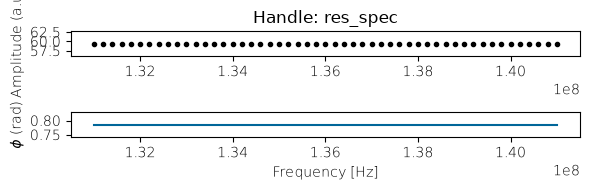

In [14]:
# plot the results
plot_results(res_spec_results, phase=True)

In [15]:
# get the measurement data returned by the instruments from the LabOne Q session
spec_res = res_spec_results.get_data("res_spec")

# define the frequency axis from the qubit parameters
spec_freq = lo_settings['ro_lo'] + res_spec_results.get_axis("res_spec")[0]

print(spec_res)
print(spec_freq)

[42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j
 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j
 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j
 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j
 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j
 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j 42.+42.j
 42.+42.j 42.+42.j 42.+42.j]
[6.3310e+09 6.3312e+09 6.3314e+09 6.3316e+09 6.3318e+09 6.3320e+09
 6.3322e+09 6.3324e+09 6.3326e+09 6.3328e+09 6.3330e+09 6.3332e+09
 6.3334e+09 6.3336e+09 6.3338e+09 6.3340e+09 6.3342e+09 6.3344e+09
 6.3346e+09 6.3348e+09 6.3350e+09 6.3352e+09 6.3354e+09 6.3356e+09
 6.3358e+09 6.3360e+09 6.3362e+09 6.3364e+09 6.3366e+09 6.3368e+09
 6.3370e+09 6.3372e+09 6.3374e+09 6.3376e+09 6.3378e+09 6.3380e+09
 6.3382e+09 6.3384e+09 6.3386e+09 6.3388e+09 6.3390e+09 6.3392e+09
 6.3394e+09 6.3396e+09 6.3398e+09 6.3400e+09 6.3402e+09 6.3404e+

# 3. Pulsed Qubit Spectroscopy

#### Parameters

In [16]:
qubit_parameters['qb_len_spec'] = 20e-6
qubit_parameters['qb_amp_spec'] = 0.6

In [17]:
# pulse parameters and definitions
envelop_duration = 2.0e-6
sigma = 0.2
flat_duration = 1.0e-6
drive_length = 1e-6

In [18]:
def create_readout_pulse(
        qubit, length=envelop_duration, amplitude=0.9, width=flat_duration, sigma=sigma
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
        width=width,
        sigma=sigma,
    )
    return readout_pulse

def create_drive_spec_pulse(qubit, length=drive_length, amplitude=0.9):
    pulse = pulse_library.const(
        uid=f"drive_spec_pulse_{qubit}", length=length, amplitude=amplitude
    )
    return pulse

def create_drive_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"drive_freq_{qubit}", start=start_freq, stop=stop_freq, count=num_points
    )

In [19]:
# function that returns a qubit spectroscopy experiment - accepts frequency sweep range as parameter

def qubit_spectroscopy(freq_sweep, drive_pulse, readout_pulse):
    # Create qubit spectroscopy Experiment - uses qubit drive, readout drive and data acquisition lines
    exp_qspec = Experiment(
        uid="Qubit Spectroscopy",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    # inner loop - real-time averaging - QA in integration mode
    with exp_qspec.acquire_loop_rt(
        uid="freq_shots",
        count=2**num_averages,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        with exp_qspec.sweep(uid="qfreq_sweep", parameter=freq_sweep):
            # qubit drive
            with exp_qspec.section(uid="qubit_excitation"):
                exp_qspec.play(signal="drive", pulse=drive_pulse)
            with exp_qspec.section(
                uid="readout_section", play_after="qubit_excitation"
            ):
                # play readout pulse on measure line
                exp_qspec.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_qspec.acquire(
                    signal="acquire",
                    handle="qb_spec",
                    kernel=readout_pulse,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_qspec.section(uid="relax", length=1e-6):
                exp_qspec.reserve(signal="measure")

    return exp_qspec

In [20]:
# frequency range of spectroscopy scan - defined around expected qubit frequency as defined in qubit parameters
qspec_range = 100e6
# how many frequency points to measure
qspec_num = 1001
freq_sweep_q0 = create_drive_freq_sweep("q0", -qspec_range, qspec_range, qspec_num)

# experiment signal calibration for qubit 0
exp_calibration_q0 = Calibration()
exp_calibration_q0["drive"] = SignalCalibration(
    oscillator=Oscillator(
        frequency=freq_sweep_q0,
        modulation_type=ModulationType.HARDWARE,
    ),
)


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "drive"
        ],
        "measure": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "measure"
        ],
        "acquire": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "acquire"
        ],
    }
    return signal_map


# define experiment with frequency sweep for qubit 0
drive_pulse = create_drive_spec_pulse("q0")
readout_pulse = create_readout_pulse("q0", sigma=0.2, width=1e-6)

exp_qspec = qubit_spectroscopy(freq_sweep_q0, drive_pulse, readout_pulse)

# apply calibration and signal map for qubit 0
exp_qspec.set_calibration(exp_calibration_q0)
exp_qspec.set_signal_map(signal_map_default("q0"))

In [21]:
# compile the experiment on the open instrument session
compiled_qspec = session.compile(exp_qspec)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Qubit_Spectroscopy", compiled_qspec)

[2026.06.30 15:58:09.618] INFO    Starting LabOne Q Compiler run...
[2026.06.30 15:58:09.622] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 15:58:09.624] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 15:58:09.632] INFO    Schedule completed. [0.008 s]
[2026.06.30 15:58:09.657] INFO    Code generation completed for all AWGs. [0.024 s]
[2026.06.30 15:58:09.659] INFO    Completed compilation step 1 of 1. [0.034 s]
[2026.06.30 15:58:09.660] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 15:58:09.660] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 15:58:09.661] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 15:58:09.661] INFO      shfqc_0        0         10            0           1      8000  
[2026.06.30 15:58:09.661] INFO      shfqc_0_sg     0         23            2           1 

/Users/khatran/Desktop/pico-thermometry/Pulse_Sheets/Qubit_Spectroscopy_2026-06-30-15-58-09.html

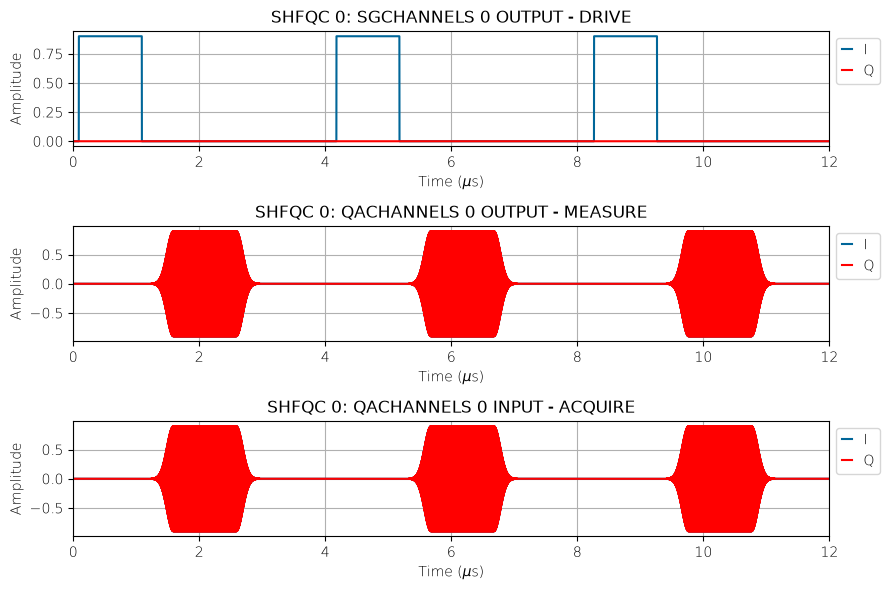

In [22]:
plot_simulation(compiled_qspec, start_time=0, length=12e-6)

In [23]:
# run the compiled experiemnt
qspec_results = session.run(compiled_qspec)
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(qspec_results, f"Results/{timestamp}_qspec_results.json")
print(f"File saved as Results/{timestamp}_qspec_results.json")

[2026.06.30 15:58:09.887] INFO    Starting near-time execution...
[2026.06.30 15:58:09.891] INFO    Estimated RT execution time: 33.52 s.
[2026.06.30 15:58:09.902] INFO    Finished near-time execution.
File saved as Results/20260630T155809_qspec_results.json


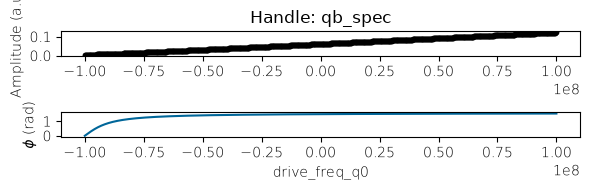

In [24]:
plot_results(qspec_results, phase=True)

# 4. Amplitude Rabi

In [25]:
# range of pulse amplitude scan


def create_rabi_amp_sweep(amp_num, uid="rabi_amp"):
    amp_min = 0
    amp_max = 1
    return LinearSweepParameter(uid=uid, start=amp_min, stop=amp_max, count=amp_num)


# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 4


# pulse parameters and definitions
envelope_duration = 2.0e-6
sigma = 0.2
flat_duration = 1.0e-6


def create_readout_pulse(
    qubit, length=envelope_duration, amplitude=0.9, width=flat_duration, sigma=sigma
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
        width=width,
        sigma=sigma,
    )
    return readout_pulse


def create_rabi_drive_pulse(qubit, length=1e-6, amplitude=0.9):
    return pulse_library.gaussian(
        uid=f"gaussian_drive_q{qubit}", length=length, amplitude=amplitude
    )

In [26]:
# function that returns an amplitude Rabi experiment


def amplitude_rabi(drive_pulse, readout_pulse, amplitude_sweep):
    exp_rabi = Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_rabi.acquire_loop_rt(
        uid="rabi_shots",
        count=num_averages,
        averaging_mode=AveragingMode.CYCLIC,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        # inner loop - real time sweep of Rabi ampitudes
        with exp_rabi.sweep(uid="rabi_sweep", parameter=amplitude_sweep):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_rabi.section(
                uid="qubit_excitation", alignment=SectionAlignment.RIGHT
            ):
                exp_rabi.play(
                    signal="drive", pulse=drive_pulse, amplitude=amplitude_sweep
                )
            # readout pulse and data acquisition
            with exp_rabi.section(uid="readout_section", play_after="qubit_excitation"):
                # play readout pulse on measure line
                exp_rabi.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_rabi.acquire(
                    signal="acquire",
                    handle="amp_rabi",
                    kernel=readout_pulse,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_rabi.section(uid="reserve", length=1e-6):
                exp_rabi.reserve(signal="measure")
    return exp_rabi

In [27]:
# define pulses and create experiment
readout_pulse = create_readout_pulse("q0")
drive_pulse = create_rabi_drive_pulse("q0")
exp_rabi = amplitude_rabi(drive_pulse, readout_pulse, create_rabi_amp_sweep(amp_num=61))


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "drive"
        ],
        "measure": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "measure"
        ],
        "acquire": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "acquire"
        ],
    }
    return signal_map


# run the experiment on qubit 0
exp_rabi.set_signal_map(signal_map_default("q0"))

In [28]:
# compile the experiment on the open instrument session
compiled_rabi = session.compile(exp_rabi)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Rabi", compiled_rabi)

[2026.06.30 15:58:09.996] INFO    Starting LabOne Q Compiler run...
[2026.06.30 15:58:09.996] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 15:58:09.997] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 15:58:09.997] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 15:58:09.997] INFO    Schedule completed. [0.000 s]
[2026.06.30 15:58:10.004] INFO    Code generation completed for all AWGs. [0.006 s]
[2026.06.30 15:58:10.004] INFO    Completed compilation step 1 of 1. [0.007 s]
[2026.06.30 15:58:10.006] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 15:58:10.006] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 15:58:10.006] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 15:58:10.006] INFO      shfqc_0        0         10            0          

/Users/khatran/Desktop/pico-thermometry/Pulse_Sheets/Rabi_2026-06-30-15-58-10.html

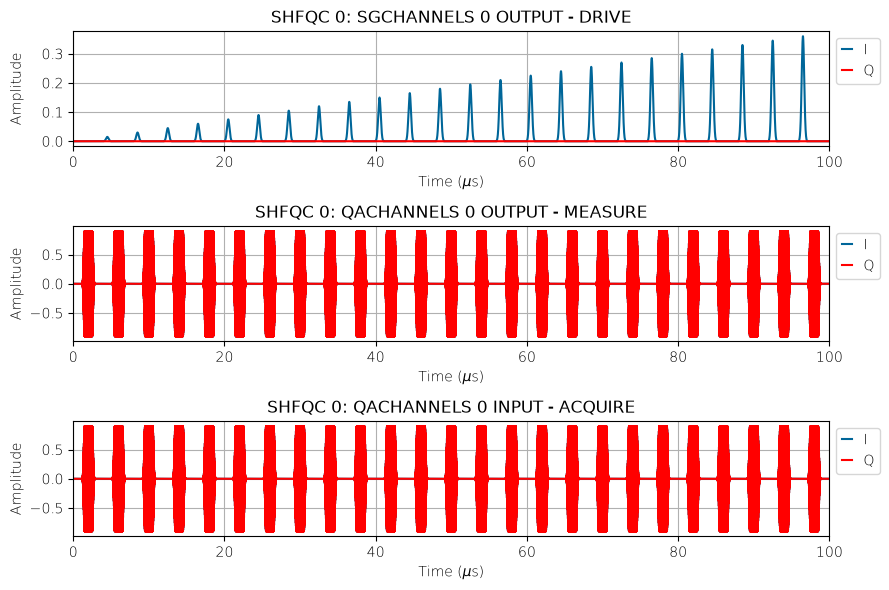

In [29]:
plot_simulation(compiled_rabi, start_time=0, length=100e-6)

In [30]:
# run the compiled experiemnt
rabi_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(rabi_results, f"Results/{timestamp}_rabi_results.json")
print(f"File saved as Results/{timestamp}_rabi_results.json")

[2026.06.30 15:58:10.345] INFO    Starting near-time execution...
[2026.06.30 15:58:10.359] INFO    Finished near-time execution.
File saved as Results/20260630T155810_rabi_results.json


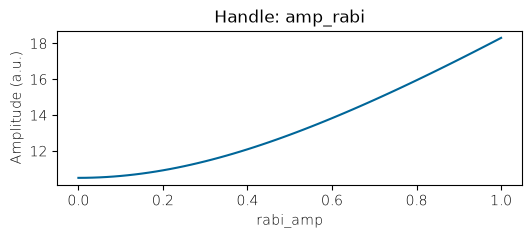

In [31]:
plot_results(rabi_results)

Fitted parameters: [10.07865552 -0.03757429  0.99697936  1.30070908]


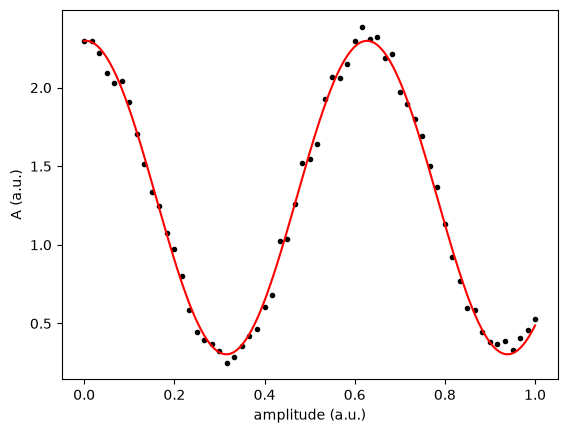

In [32]:
# get measurement data returned by the instruments
rabi_res = rabi_results.get_data("amp_rabi")

# define amplitude axis from qubit parameters
rabi_amp = rabi_results.get_axis("amp_rabi")[0]

if use_emulation:
    # create some dummy data if running in emulation mode
    rabi_res = oscillatory(rabi_amp, 10, 0, 1, 1.2) + 0.2 * np.random.rand(
        len(rabi_amp)
    )

# plot measurement data
fig = plt.figure()
plt.plot(rabi_amp, rabi_res, ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("amplitude (a.u.)")

# increase number of plot points for smooth plotting of fit results
amp_plot = np.linspace(rabi_amp[0], rabi_amp[-1], 5 * len(rabi_amp))

# fit measurement results - assume sinusoidal oscillation with drive amplitude
popt, pcov = oscillatory.fit(rabi_amp, rabi_res, 10, 0, 1, 1.2, plot=False)
print(f"Fitted parameters: {popt}")

# plot fit results together with measurement data
plt.plot(amp_plot, oscillatory(amp_plot, *popt), "-r")
plt.show()

# 5. Ramsey

In [33]:
def create_readout_pulse(
    qubit, length=envelope_duration, amplitude=0.9, width=flat_duration, sigma=sigma
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
        width=width,
        sigma=sigma,
    )
    return readout_pulse


def create_ramsey_drive_pulse(qubit, length=1e-6, amplitude=0.9):
    return pulse_library.gaussian(
        uid=f"gaussian_drive_q{qubit}", length=length, amplitude=amplitude
    )


# define delay sweep
n_steps = 201
start_delay = 0e-6
stop_delay = 15e-6


def create_delay_sweep(
    start=start_delay, stop=stop_delay, count=n_steps, axis_name="Time [s]"
):
    time_sweep = LinearSweepParameter(
        uid="time_sweep_param", start=start, stop=stop, count=count, axis_name=axis_name
    )
    return time_sweep

In [34]:
# function that returns an amplitude Rabi experiment


def ramsey(drive_pulse, readout_pulse, time_sweep):
    exp_ramsey = Experiment(
        uid="Ramsey Experiment",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_ramsey.acquire_loop_rt(
        uid="ramsey_shots",
        count=2**num_averages,
        averaging_mode=AveragingMode.CYCLIC,
        acquisition_type=AcquisitionType.INTEGRATION,
        repetition_mode=RepetitionMode.AUTO,
    ):
        # inner loop - real time sweep of Ramsey time delays
        with exp_ramsey.sweep(
            uid="ramsey_sweep", parameter=time_sweep, alignment=SectionAlignment.RIGHT
        ):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_ramsey.section(
                uid="qubit_excitation", alignment=SectionAlignment.RIGHT
            ):
                exp_ramsey.play(signal="drive", pulse=drive_pulse)
                exp_ramsey.delay(signal="drive", time=time_sweep)
                exp_ramsey.play(signal="drive", pulse=drive_pulse)
            # readout pulse and data acquisition
            with exp_ramsey.section(
                uid="readout_section", play_after="qubit_excitation"
            ):
                # play readout pulse on measure line
                exp_ramsey.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_ramsey.acquire(
                    signal="acquire",
                    handle="ramsey",
                    kernel=readout_pulse,
                )

            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_ramsey.section(uid="relax", length=1e-6):
                exp_ramsey.reserve(signal="measure")
    return exp_ramsey

In [35]:
# define pulses and create experiment
readout_pulse = create_readout_pulse("q0")
drive_pulse = create_ramsey_drive_pulse("q0")
time_sweep = create_delay_sweep(start=0, stop=15e-6, count=51)

ramsey_exp = ramsey(
    drive_pulse=drive_pulse, readout_pulse=readout_pulse, time_sweep=time_sweep
)


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "drive"
        ],
        "measure": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "measure"
        ],
        "acquire": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "acquire"
        ],
    }
    return signal_map


# run the experiment on qubit 0
ramsey_exp.set_signal_map(signal_map_default("q0"))

In [36]:
# compile the experiment on the open instrument session
compiled_ramsey = session.compile(ramsey_exp)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Ramsey", compiled_ramsey)

[2026.06.30 15:58:10.458] INFO    Starting LabOne Q Compiler run...
[2026.06.30 15:58:10.459] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 15:58:10.459] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 15:58:10.459] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 15:58:10.460] INFO    Schedule completed. [0.000 s]
[2026.06.30 15:58:10.462] INFO    Code generation completed for all AWGs. [0.002 s]
[2026.06.30 15:58:10.462] INFO    Completed compilation step 1 of 1. [0.003 s]
[2026.06.30 15:58:10.464] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 15:58:10.464] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 15:58:10.464] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 15:58:10.464] INFO      shfqc_0        0         10            0          

/Users/khatran/Desktop/pico-thermometry/Pulse_Sheets/Ramsey_2026-06-30-15-58-10.html

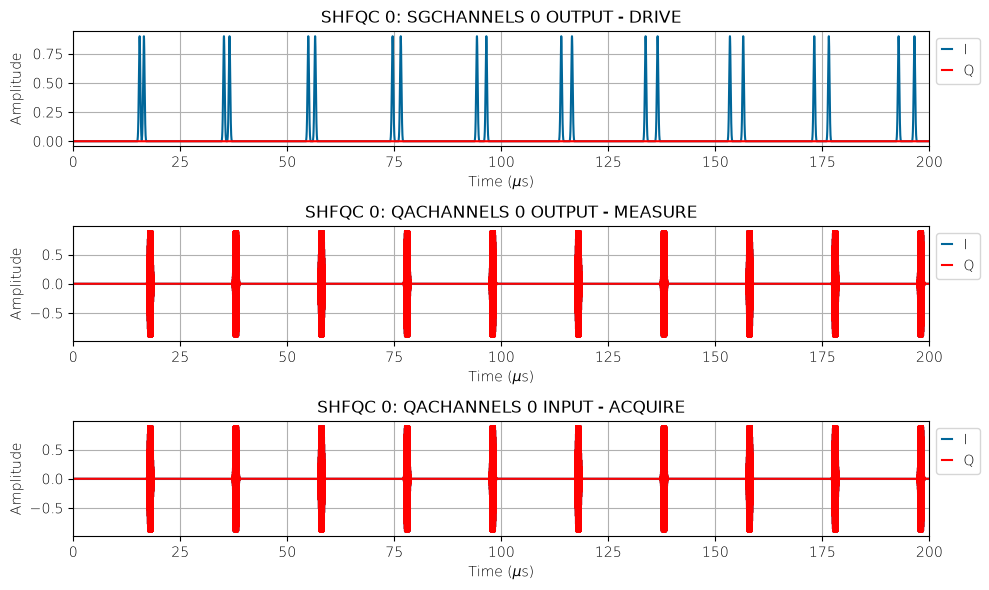

In [37]:
plot_simulation(compiled_ramsey, start_time=0, length=200e-6, plot_width=10)

In [38]:
# run the compiled experiemnt
ramsey_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(ramsey_results, f"Results/{timestamp}_ramsey_results.json")
print(f"File saved as Results/{timestamp}_ramsey_results.json")

[2026.06.30 15:58:10.766] INFO    Starting near-time execution...
[2026.06.30 15:58:10.780] INFO    Finished near-time execution.
File saved as Results/20260630T155810_ramsey_results.json


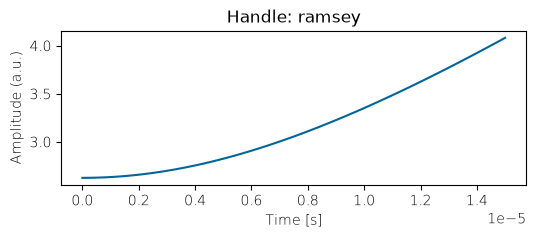

In [39]:
# plot_result_2d(ramsey_results, list(ramsey_results.acquired_results.keys())[0])
plot_results(ramsey_results)

Fitted parameters: [ 1.00579154e+06 -7.77300134e-02  9.31974269e+04  4.87165446e-01
  5.59205166e-01]


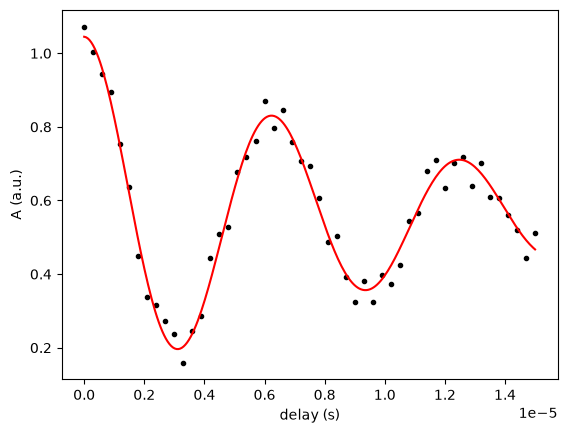

In [40]:
# get measurement data returned by the instruments
ramsey_res = ramsey_results.get_data("ramsey")

# define time axis from qubit parameters
ramsey_delay = ramsey_results.get_axis("ramsey")[0]

if use_emulation:
    # create dummy data if running in emulation mode
    ramsey_res = oscillatory_decay(
        ramsey_delay, 1e6, 0, 1 / 10e-6, amplitude=0.5, offset=0.5
    ) + 0.12 * np.random.rand(len(ramsey_delay))

# plot measurement results
fig = plt.figure()
plt.plot(ramsey_delay, ramsey_res, ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("delay (s)")

# increase number of plot points for smooth plotting of fit results
delay_plot = np.linspace(ramsey_delay[0], ramsey_delay[-1], 5 * len(ramsey_delay))

## fit measurement data to decaying sinusoidal oscillatio
popt, pcov = oscillatory_decay.fit(
    ramsey_delay,
    ramsey_res,
    1e6,
    0,
    2 / 1 / 10e-6,
    0.5,
    0.5,
    plot=False,
    bounds=[
        [0.01e6, -np.pi / 2, 0.1 / 1 / 10e-6, 0.2, 0.2],
        [15e6, np.pi / 2, 10 / 1 / 10e-6, 2, 2],
    ],
)
print(f"Fitted parameters: {popt}")

# plot fit results together with experimental data
plt.plot(delay_plot, oscillatory_decay(delay_plot, *popt), "-r")
plt.show()

# 6. DRAG Calibration

In [41]:
## define pulses

# qubit pi-pulse for first excited state
x180 = pulse_library.drag(uid="x180", length=24e-9, amplitude=0.5, sigma=0.3, beta=0.2)

# long spectroscopy pulse for e-f transition - frequency will be swept
ef_spec_pulse = pulse_library.const(uid="ef_pulse", length=10e-6, amplitude=1.0)

# readout drive pulse
readout_pulse = pulse_library.const(uid="readout_pulse", length=400e-9, amplitude=0.2)
# readout integration weights
readout_weighting_function = pulse_library.const(
    uid="readout_weighting_function", length=400e-9, amplitude=0.8
)

In [42]:
# set up sweep parameter - drive amplitude
start = 25e6
stop = 250e6
count = 25
frequency_sweep = LinearSweepParameter(
    uid="frequency", start=start, stop=stop, count=count
)

# number of averages
average_exponent = 10  # used for 2^n averages, n=average_exponent, maximum: n = 17

# Create Experiment
exp_ef_spec = Experiment(
    uid="e-f spectroscopy",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("drive_ef"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)
## experimental pulse sequence
# outer loop - real-time, cyclic averaging in standard integration mode
with exp_ef_spec.acquire_loop_rt(
    uid="shots",
    count=pow(2, average_exponent),
    averaging_mode=AveragingMode.CYCLIC,
    acquisition_type=AcquisitionType.INTEGRATION,
):
    # inner loop - real-time frequency sweep of qubit e-f drive pulse
    with exp_ef_spec.sweep(uid="sweep", parameter=frequency_sweep):
        # qubit excitation - pulse amplitude will be swept
        with exp_ef_spec.section(
            uid="qubit_excitation",
            on_system_grid=True,
            alignment=SectionAlignment.RIGHT,
        ):
            exp_ef_spec.play(signal="drive", pulse=x180)
        with exp_ef_spec.section(
            uid="qubit_ef_excitation",
            play_after="qubit_excitation",
            on_system_grid=True,
            alignment=SectionAlignment.RIGHT,
        ):
            exp_ef_spec.play(signal="drive_ef", pulse=ef_spec_pulse)
        # qubit readout pulse and data acquisition
        with exp_ef_spec.section(uid="qubit_readout", play_after="qubit_ef_excitation"):
            # play readout pulse
            exp_ef_spec.play(signal="measure", pulse=readout_pulse)
            # signal data acquisition
            exp_ef_spec.acquire(
                signal="acquire",
                handle="ac_0",
                kernel=readout_weighting_function,
            )
        # relax time after readout - for signal processing and qubit relaxation to groundstate
        with exp_ef_spec.section(uid="relax", length=100e-9):
            exp_ef_spec.reserve(signal="measure")

In [43]:
# define signal maps for qubit 0
map_q0 = {
    "drive": q0.signals["drive"],
    "drive_ef": q0.signals["drive_ef"],
    "measure": q0.signals["measure"],
    "acquire": q0.signals["acquire"],
}
# ... - and qubit 1
map_q1 = {
    "drive": q1.signals["drive"],
    "drive_ef": q1.signals["drive_ef"],
    "measure": q1.signals["measure"],
    "acquire": q1.signals["acquire"],
}

In [44]:
# define experiment calibration
exp_calibration = Calibration(
    {
        "drive_ef": SignalCalibration(
            oscillator=Oscillator(
                # WORKAROUND: when sweeping an oscillator on a logical line using the oscillator switching feature, need to ensure that the uid of the swept oscillator is sorted() first
                uid="ef_drive_osc",
                frequency=frequency_sweep,
                modulation_type=ModulationType.HARDWARE,
            )
        )
    }
)

In [45]:
# set signal map to qubit 0
exp_ef_spec.set_signal_map(map_q0)
exp_ef_spec.set_calibration(exp_calibration)

# run experiment on qubit 0
compiled_exp_ef_spec = session.compile(exp_ef_spec)

ef_espec_results = session.run(compiled_exp_ef_spec)

[2026.06.30 16:01:02.139] INFO    Starting LabOne Q Compiler run...
[2026.06.30 16:01:02.146] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 16:01:02.146] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 16:01:02.147] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 16:01:02.147] INFO    Schedule completed. [0.000 s]
[2026.06.30 16:01:02.158] INFO    Code generation completed for all AWGs. [0.010 s]
[2026.06.30 16:01:02.159] INFO    Completed compilation step 1 of 1. [0.012 s]
[2026.06.30 16:01:02.161] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 16:01:02.162] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 16:01:02.162] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 16:01:02.162] INFO      shfqc_0        0         10            0          

In [46]:
show_pulse_sheet("ef_spectroscopy", compiled_exp_ef_spec)

[2026.06.30 16:01:09.987] INFO    Recompiling the experiment due to missing extra information in the compiled experiment. Compile with `OUTPUT_EXTRAS=True` and `MAX_EVENTS_TO_PUBLISH=1000` to bypass this step with a small impact on the compilation time.
[2026.06.30 16:01:09.989] INFO    Starting LabOne Q Compiler run...
[2026.06.30 16:01:09.990] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 16:01:09.990] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 16:01:09.990] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 16:01:09.994] INFO    Schedule completed. [0.004 s]
[2026.06.30 16:01:09.997] INFO    Code generation completed for all AWGs. [0.003 s]
[2026.06.30 16:01:09.998] INFO    Completed compilation step 1 of 1. [0.007 s]
[2026.06.30 16:01:10.001] INFO    Finished LabOne Q Compiler run.
[2026.06.30 16:01:10.001] WARNING Pulse sheet viewer: The event list 

/Users/khatran/Desktop/pico-thermometry/ef_spectroscopy_2026-06-30-16-01-09.html

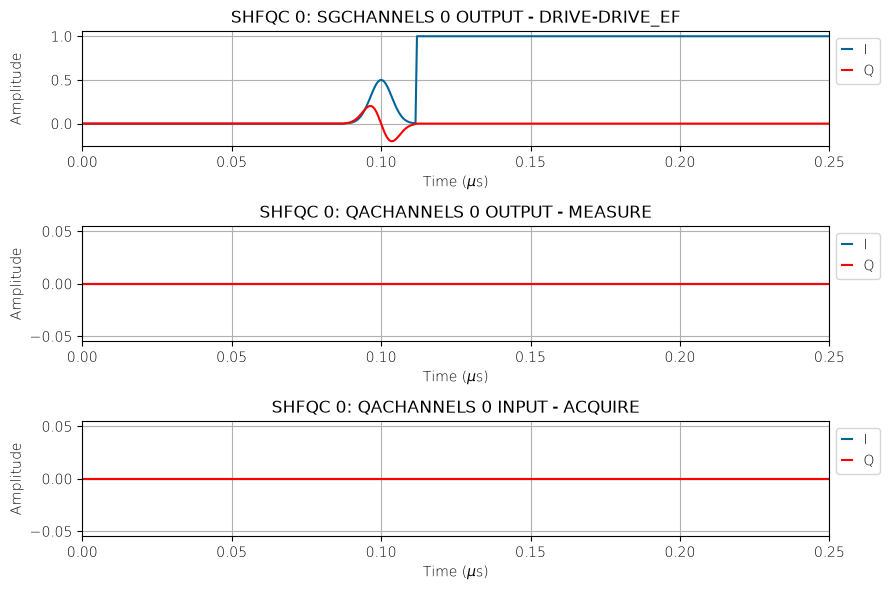

In [47]:
# Plot simulated output signals
plot_simulation(compiled_exp_ef_spec, start_time=0, length=0.25e-6)

In [48]:
## define pulses

# qubit pi pulse for first excited state
x180 = pulse_library.drag(uid="x180", length=23e-9, amplitude=0.5, sigma=0.3, beta=0.2)

# pulse to be calibrated for e-f transition - amplitude will be swept
ef_pulse = pulse_library.drag(
    uid="ef_pulse", length=32e-9, amplitude=1.0, sigma=0.3, beta=0.2
)

# readout drive pulse
readout_pulse = pulse_library.const(uid="readout_pulse", length=400e-9, amplitude=0.2)
# readout integration weights
readout_weighting_function = pulse_library.const(
    uid="readout_weighting_function", length=400e-9, amplitude=0.8
)

In [49]:
# set up sweep parameter - drive amplitude
start = 0.1
stop = 1
count = 25
amplitude_sweep = LinearSweepParameter(
    uid="amplitude", start=start, stop=stop, count=count
)

# number of averages
average_exponent = 10  # used for 2^n averages, n=average_exponent, maximum: n = 17

# Create Experiment
exp_ef_gate = Experiment(
    uid="e-f Tuneup",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("drive_ef"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)
## experimental pulse sequence
# outer loop - real-time, cyclic averaging in standard integration mode
with exp_ef_gate.acquire_loop_rt(
    uid="shots",
    count=pow(2, average_exponent),
    averaging_mode=AveragingMode.CYCLIC,
    acquisition_type=AcquisitionType.INTEGRATION,
):
    # inner loop - real-time sweep of qubit drive pulse amplitude
    with exp_ef_gate.sweep(uid="sweep", parameter=amplitude_sweep):
        # qubit excitation - pulse amplitude will be swept
        with exp_ef_gate.section(
            uid="qubit_excitation",
            on_system_grid=True,
            alignment=SectionAlignment.RIGHT,
        ):
            exp_ef_gate.play(signal="drive", pulse=x180)
        with exp_ef_gate.section(
            uid="qubit_ef_excitation",
            play_after="qubit_excitation",
            on_system_grid=True,
            alignment=SectionAlignment.LEFT,
        ):
            exp_ef_gate.play(
                signal="drive_ef", pulse=ef_pulse, amplitude=amplitude_sweep
            )
        # qubit readout pulse and data acquisition
        with exp_ef_gate.section(uid="qubit_readout", play_after="qubit_ef_excitation"):
            # play readout pulse
            exp_ef_gate.play(signal="measure", pulse=readout_pulse)
            # signal data acquisition
            exp_ef_gate.acquire(
                signal="acquire",
                handle="ac_0",
                kernel=readout_weighting_function,
            )
        # relax time after readout - for signal processing and qubit relaxation to groundstate
        with exp_ef_gate.section(uid="relax", length=100e-9):
            exp_ef_gate.reserve(signal="measure")

In [50]:
# define signal maps for qubit 0
map_q0 = {
    "drive": q0.signals["drive"],
    "drive_ef": q0.signals["drive_ef"],
    "measure": q0.signals["measure"],
    "acquire": q0.signals["acquire"],
}
# ... - and qubit 1
map_q1 = {
    "drive": q1.signals["drive"],
    "drive_ef": q1.signals["drive_ef"],
    "measure": q1.signals["measure"],
    "acquire": q1.signals["acquire"],
}

In [51]:
# set signal map to qubit 0
exp_ef_gate.set_signal_map(map_q1)

# run experiment on qubit 0
compiled_exp_ef_gate = session.compile(exp_ef_gate)
ef_gate_results = session.run(compiled_exp_ef_gate)

[2026.06.30 16:22:17.087] INFO    Starting LabOne Q Compiler run...
[2026.06.30 16:22:17.094] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 16:22:17.095] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 16:22:17.095] INFO    Resolved modulation type of oscillator on signal: 'drive_ef' to Hardware
[2026.06.30 16:22:17.095] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 16:22:17.097] INFO    Schedule completed. [0.001 s]
[2026.06.30 16:22:17.104] INFO    Code generation completed for all AWGs. [0.007 s]
[2026.06.30 16:22:17.105] INFO    Completed compilation step 1 of 1. [0.009 s]
[2026.06.30 16:22:17.107] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 16:22:17.108] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 16:22:17.108] INFO     ─────────────────────────────────────────────

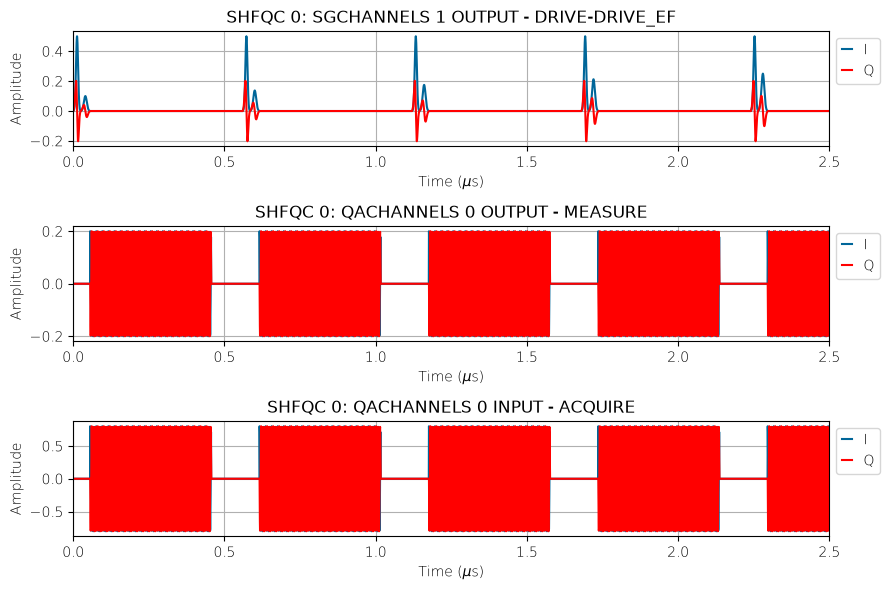

In [52]:
# Plot simulated output signals
plot_simulation(compiled_exp_ef_gate, start_time=0, length=2.5e-6)

# 7. T1 Experiment

In [54]:
#  signal map for qubit


def map_qubit(qubit):
    return {
        "drive": qubit.signals["drive"],
        "measure": qubit.signals["measure"],
        "acquire": qubit.signals["acquire"],
    }

In [55]:
## define pulses
# qubit drive pulse - use amplitude calibrated by amplitude Rabi experiment
x180 = pulse_library.gaussian(uid="x180", length=100e-9, amplitude=0.66)
# readout drive pulse
readout_pulse = pulse_library.const(uid="readout_pulse", length=400e-9, amplitude=1.0)
# readout integration weights
readout_weighting_function = pulse_library.const(
    uid="readout_weighting_function", length=400e-9, amplitude=1.0
)

In [56]:
# sweep parameter - delay before readout / after pi pulse
count = 11
start = 0
stop = 1e-6
delay_sweep = LinearSweepParameter(uid="delay", start=start, stop=stop, count=count)

# number of averages
average_exponent = 4  # used for 2^n averages, n=average_exponent, maximum: n = 17

# Create Experiment
exp = Experiment(
    uid="T1 experiment",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)
## experimental pulse sequence
# outer loop - real-time, cyclic averaging in standard integration mode
with exp.acquire_loop_rt(
    uid="shots",
    count=pow(2, average_exponent),
    averaging_mode=AveragingMode.CYCLIC,
    acquisition_type=AcquisitionType.INTEGRATION,
    repetition_mode=RepetitionMode.AUTO,  # compiler sets repetition time to shortest possible constant time
):
    # inner loop - sweep over delay between qubit excitation and readout pulse
    # right alignment makes sure the readout section follows a fixed timing, being the last element in each shot
    with exp.sweep(
        uid="sweep", parameter=delay_sweep, alignment=SectionAlignment.RIGHT
    ):
        # qubit drive pulse followed by variable delay
        with exp.section(uid="qubit_excitation", alignment=SectionAlignment.RIGHT):
            exp.play(signal="drive", pulse=x180)
            exp.delay(signal="drive", time=delay_sweep)
        # qubit readout pulse and data acquisition
        with exp.section(uid="qubit_readout", play_after="qubit_excitation"):
            # play readout pulse
            exp.play(signal="measure", pulse=readout_pulse)
            # signal data acquisition
            exp.acquire(
                signal="acquire",
                handle="ac_0",
                kernel=readout_weighting_function,
            )
        # relax time after readout - for signal processing and qubit relaxation to ground state
        with exp.section(uid="relax", length=1e-6):
            exp.reserve(signal="measure")

In [57]:
# define signal maps for qubit 0
map_q0 = {
    "drive": device_setup.logical_signal_groups["q0"].logical_signals["drive"],
    "measure": device_setup.logical_signal_groups["q0"].logical_signals["measure"],
    "acquire": device_setup.logical_signal_groups["q0"].logical_signals["acquire"],
}

In [58]:
# map exp to qubit 0
exp.set_signal_map(map_qubit(q0))

# run on qubit 0
my_results = session.run(exp)

[2026.06.30 16:51:14.638] INFO    Starting LabOne Q Compiler run...
[2026.06.30 16:51:14.655] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 16:51:14.667] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 16:51:14.668] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 16:51:14.673] INFO    Schedule completed. [0.001 s]
[2026.06.30 16:51:14.686] INFO    Code generation completed for all AWGs. [0.012 s]
[2026.06.30 16:51:14.687] INFO    Completed compilation step 1 of 1. [0.016 s]
[2026.06.30 16:51:14.742] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 16:51:14.743] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 16:51:14.744] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 16:51:14.744] INFO      shfqc_0        0         10            0          

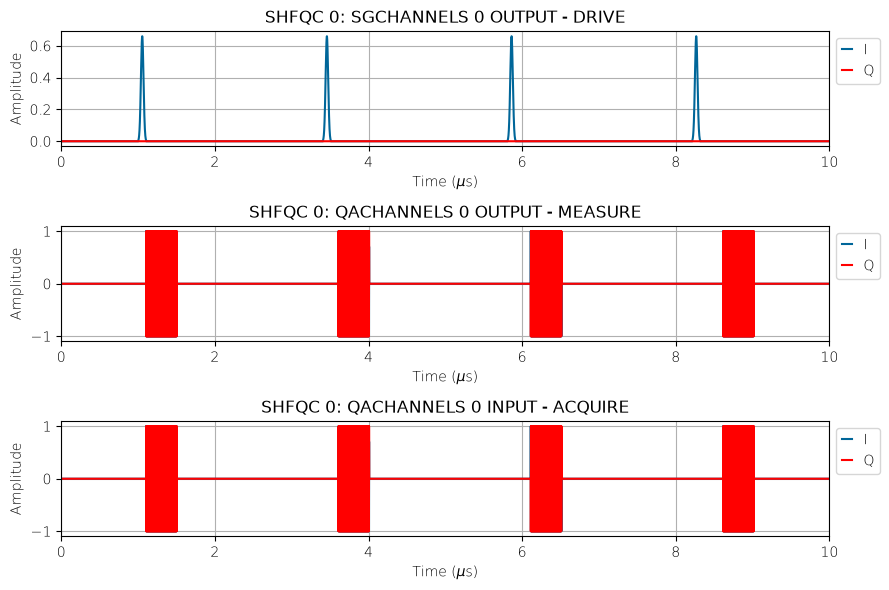

In [59]:
# Plot simulated output signals
plot_simulation(session.compiled_experiment, start_time=0, length=10e-6)

In [60]:
# plot measurement results
plot_result_2d(my_results, "ac_0")

In [66]:
# use pulse sheet viewer to display the pulse sequence - only recommended for small number of averages and sweep steps to avoid performance issues
show_pulse_sheet("Pulse_Sheets/T1", session.compiled_experiment)

[2026.06.30 17:17:43.869] INFO    Recompiling the experiment due to missing extra information in the compiled experiment. Compile with `OUTPUT_EXTRAS=True` and `MAX_EVENTS_TO_PUBLISH=1000` to bypass this step with a small impact on the compilation time.
[2026.06.30 17:17:43.911] INFO    Starting LabOne Q Compiler run...
[2026.06.30 17:17:43.920] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 17:17:43.921] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 17:17:43.921] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 17:17:43.925] INFO    Schedule completed. [0.003 s]
[2026.06.30 17:17:43.932] INFO    Code generation completed for all AWGs. [0.006 s]
[2026.06.30 17:17:43.932] INFO    Completed compilation step 1 of 1. [0.010 s]
[2026.06.30 17:17:43.952] INFO    Finished LabOne Q Compiler run.
[2026.06.30 17:17:43.952] WARNING Pulse sheet viewer: The event list 

/Users/khatran/Desktop/pico-thermometry/Pulse_Sheets/T1_2026-06-30-17-17-43.html

In [67]:
# map exp to qubit 1
exp.set_signal_map(map_qubit(q1))

# run on qubit 1
my_results = session.run(exp)

[2026.06.30 17:17:44.771] INFO    Starting LabOne Q Compiler run...
[2026.06.30 17:17:44.773] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 17:17:44.773] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 17:17:44.774] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 17:17:44.774] INFO    Schedule completed. [0.000 s]
[2026.06.30 17:17:44.776] INFO    Code generation completed for all AWGs. [0.002 s]
[2026.06.30 17:17:44.776] INFO    Completed compilation step 1 of 1. [0.002 s]
[2026.06.30 17:17:44.780] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 17:17:44.780] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 17:17:44.781] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 17:17:44.781] INFO      shfqc_0        0         10            0          

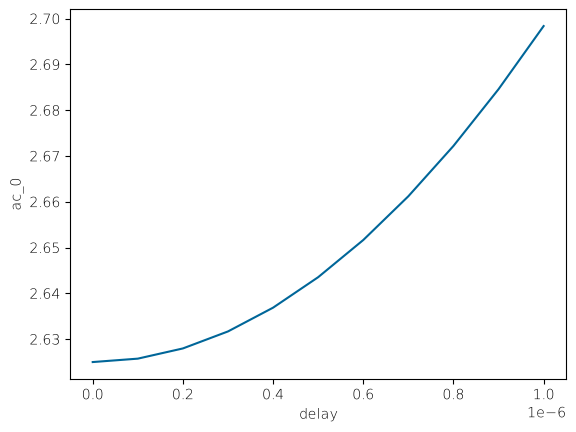

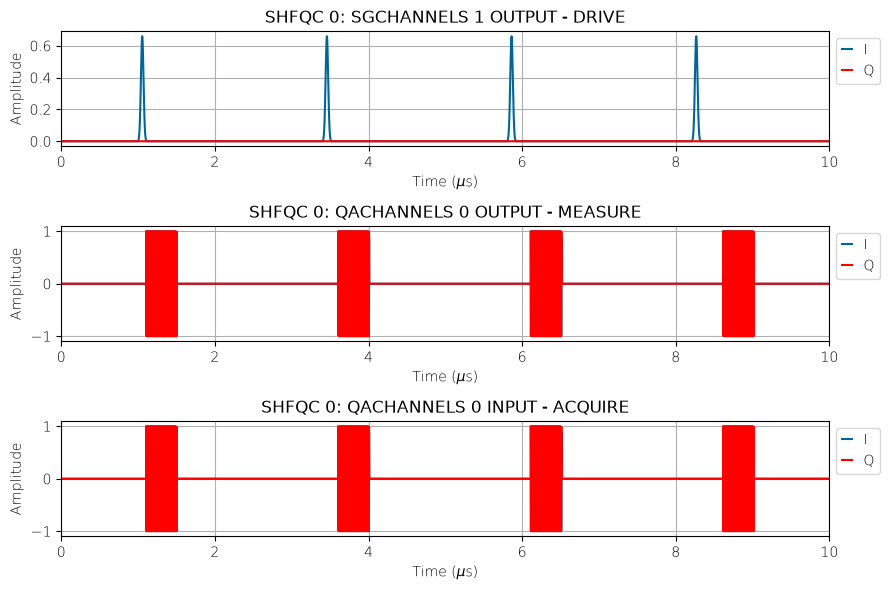

In [68]:
# Plot simulated output signals
plot_simulation(session.compiled_experiment, start_time=0, length=10e-6)

In [69]:
# plot measurement results
plot_result_2d(my_results, "ac_0")

In [70]:
# use pulse sheet viewer to display the pulse sequence - only recommended for small number of averages and sweep steps to avoid performance issues
show_pulse_sheet("Pulse_Sheets/T1", session.compiled_experiment)

[2026.06.30 17:17:54.192] INFO    Recompiling the experiment due to missing extra information in the compiled experiment. Compile with `OUTPUT_EXTRAS=True` and `MAX_EVENTS_TO_PUBLISH=1000` to bypass this step with a small impact on the compilation time.
[2026.06.30 17:17:54.194] INFO    Starting LabOne Q Compiler run...
[2026.06.30 17:17:54.194] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 17:17:54.195] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 17:17:54.195] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 17:17:54.207] INFO    Schedule completed. [0.011 s]
[2026.06.30 17:17:54.210] INFO    Code generation completed for all AWGs. [0.002 s]
[2026.06.30 17:17:54.210] INFO    Completed compilation step 1 of 1. [0.014 s]
[2026.06.30 17:17:54.213] INFO    Finished LabOne Q Compiler run.
[2026.06.30 17:17:54.213] WARNING Pulse sheet viewer: The event list 

/Users/khatran/Desktop/pico-thermometry/Pulse_Sheets/T1_2026-06-30-17-17-54.html